# **Bubble Plots**


In this lab, you will focus on visualizing data.

The dataset will be directly loaded into pandas for analysis and visualization.

You will use various visualization techniques to explore the data and uncover key trends.


## Objectives


In this lab, you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two data features.

-   Visualize composition of data.

-   Visualize comparison of data.


#### Setup: Working with the Database
**Install and import the needed libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

**Download and connect to the database file containing survey data.**


To start, download and load the dataset into a `pandas` DataFrame.



In [2]:
# Step 1: Download the dataset
!wget -O survey-data.csv https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv

# Load the data
df = pd.read_csv("survey-data.csv")

# Display the first few rows of the data to understand its structure
df.head()


--2026-03-16 15:38:49--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 159525875 (152M) [text/csv]
Saving to: ‘survey-data.csv’

survey-data.csv     100%[===================>] 152.13M  99.6MB/s    in 1.5s    

2026-03-16 15:38:51 (99.6 MB/s) - ‘survey-data.csv’ saved [159525875/159525875]



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN


### Task 1: Exploring Data Distributions Using Bubble Plots


#### 1. Bubble Plot for Age vs. Frequency of Participation


- Visualize the relationship between respondents’ age and their participation frequency (`SOPartFreq`) using a bubble plot.

- Use the size of the bubbles to represent their job satisfaction (`JobSat`).


/tmp/ipykernel_152/350804788.py:35: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg1 = df_plot1.groupby(['Age', 'SOPartFreq']).agg(


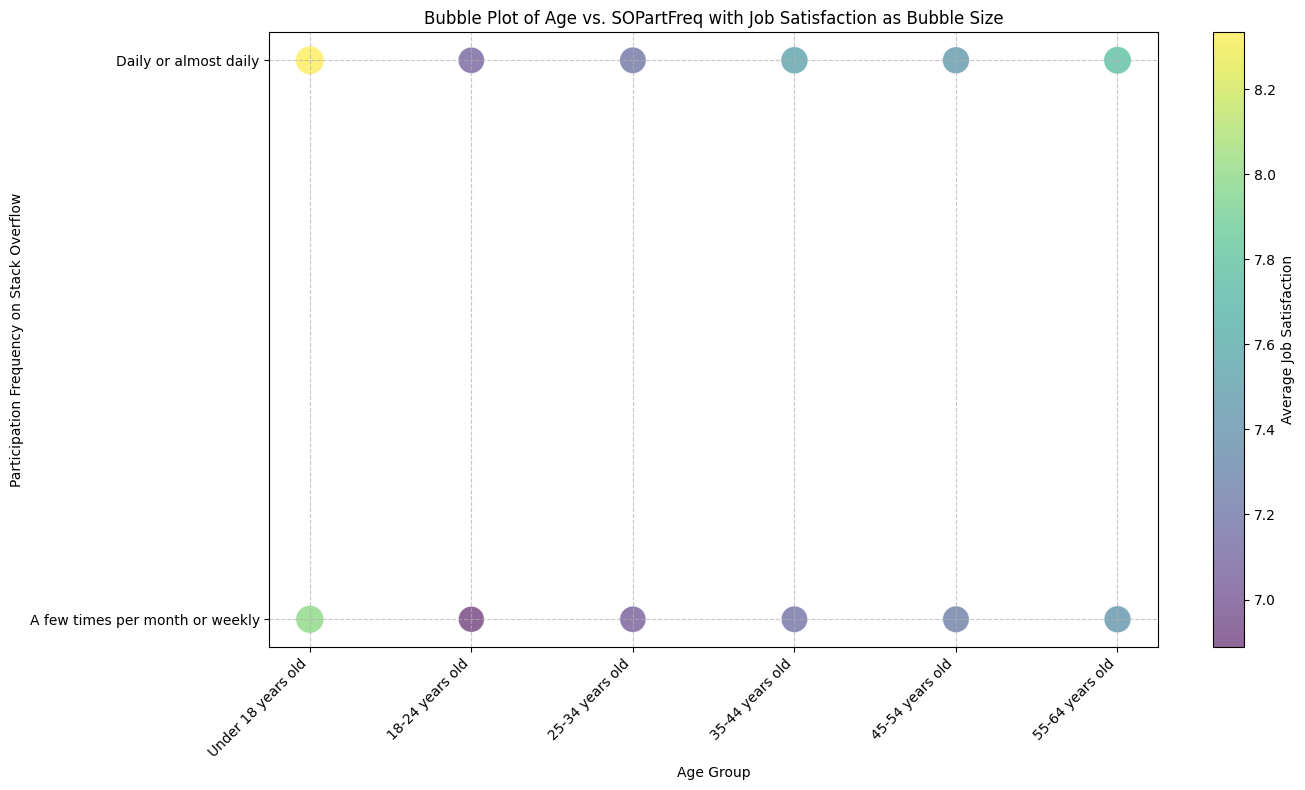

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Drop rows where any of the relevant columns are NaN for this plot
df_plot1 = df.dropna(subset=['Age', 'SOPartFreq', 'JobSat']).copy()

# Define a consistent order for 'Age' and 'SOPartFreq' for better visualization
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years old or older'
]

sopartfreq_order = [
    'Never',
    'Once a year',
    'Less than once a month or monthly',
    'A few times per month or weekly',
    'Daily or almost daily'
]

df_plot1['Age'] = pd.Categorical(df_plot1['Age'], categories=age_order, ordered=True)
df_plot1['SOPartFreq'] = pd.Categorical(df_plot1['SOPartFreq'], categories=sopartfreq_order, ordered=True)

# Convert JobSat to numeric. It might be already, but ensure for safety.
df_plot1['JobSat'] = pd.to_numeric(df_plot1['JobSat'])

# Aggregate data: calculate mean JobSat and count of respondents for each Age-SOPartFreq group
# The count will determine the size of the bubble if JobSat is not suitable for size, but the prompt asks for JobSat as size
# So, let's use JobSat directly for size. We will also calculate the count to use as a proxy for 'support' if needed for scaling.
df_agg1 = df_plot1.groupby(['Age', 'SOPartFreq']).agg(
    mean_job_sat=('JobSat', 'mean'),
    count_respondents=('ResponseId', 'count')
).reset_index()

# Scale JobSat for bubble size (adjust multiplier as needed for visual clarity)
# We'll use the mean_job_sat directly as the size, but scale it up for visibility.
# If JobSat values are small, multiplying them can make them visible.
size_multiplier = 50
df_agg1['bubble_size'] = df_agg1['mean_job_sat'] * size_multiplier

# Create the bubble plot
plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    x=df_agg1['Age'],
    y=df_agg1['SOPartFreq'],
    s=df_agg1['bubble_size'],  # Size determined by scaled mean JobSat
    alpha=0.6,
    c=df_agg1['mean_job_sat'],  # Color determined by mean JobSat
    cmap='viridis',             # Color map
    edgecolors='w',             # White edges for better visibility of bubbles
    linewidth=0.5
)

# Add a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Average Job Satisfaction')

# Add labels and title
plt.xlabel('Age Group')
plt.ylabel('Participation Frequency on Stack Overflow')
plt.title('Bubble Plot of Age vs. SOPartFreq with Job Satisfaction as Bubble Size')

# Rotate x-axis labels if they are too long
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Compensation vs. Job Satisfaction


-Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSat`).

- Use the size of the bubbles to represent respondents’ age.


/tmp/ipykernel_152/1954608988.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg2 = df_plot2.groupby(['ConvertedCompYearly', 'JobSat', 'Age']).agg(


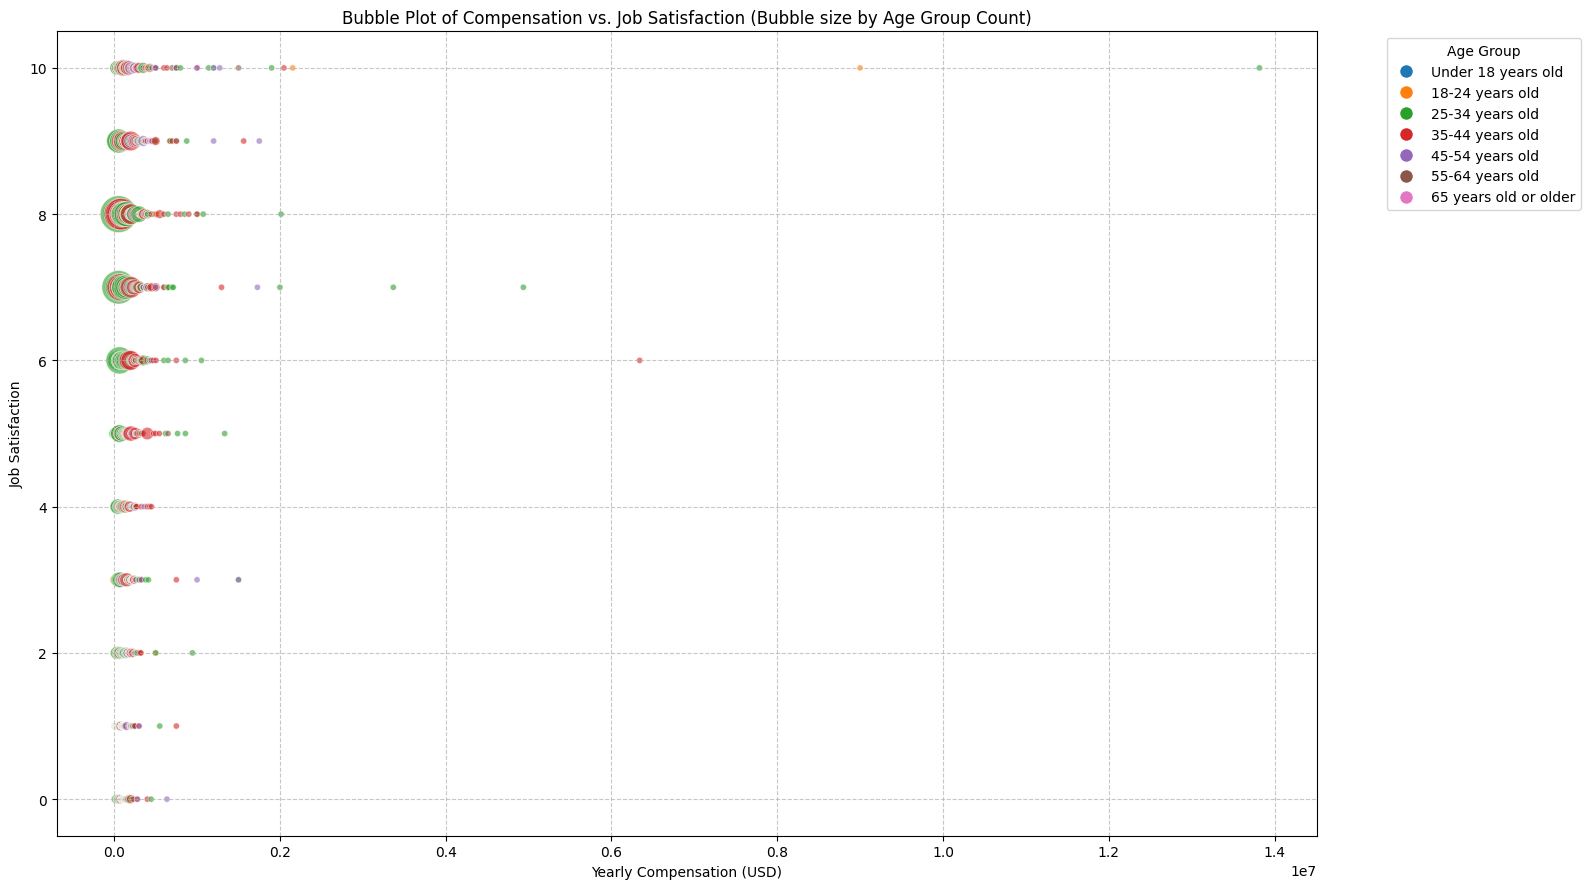

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Drop rows where any of the relevant columns are NaN for this plot
df_plot2 = df.dropna(subset=['ConvertedCompYearly', 'JobSat', 'Age']).copy()

# Convert JobSat and ConvertedCompYearly to numeric, handling potential errors
df_plot2['JobSat'] = pd.to_numeric(df_plot2['JobSat'], errors='coerce')
df_plot2['ConvertedCompYearly'] = pd.to_numeric(df_plot2['ConvertedCompYearly'], errors='coerce')

# Drop rows where conversion resulted in NaN
df_plot2.dropna(subset=['JobSat', 'ConvertedCompYearly'], inplace=True)

# Define a consistent order for 'Age' for better visualization if used as a categorical axis
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years old or older'
]

df_plot2['Age'] = pd.Categorical(df_plot2['Age'], categories=age_order, ordered=True)

# For bubble size, we need to map age categories to a numeric scale. We can use a simple mapping or average per age group.
# A simpler approach for bubble size representing age is to count occurrences per age group for each point if we want to show 'popularity' of an age at a given (comp, job_sat) point.
# However, the prompt asks to 'use the size of the bubbles to represent respondents’ age'. This implies that each bubble (representing a unique combination of ConvertedCompYearly and JobSat) should have a size based on the age of the respondents at that point.
# If we group by ConvertedCompYearly and JobSat, and then show the 'age' as size, we need to decide how to represent age (e.g., average age, or an 'age group score').
# Let's consider grouping by ConvertedCompYearly and JobSat, and then using the count of respondents within an age group for the bubble size for that age group.
# This means we'll have multiple bubbles at similar (Comp, JobSat) coordinates, colored by age, and sized by the count of respondents of that age group at that point.

# Let's simplify and make one bubble per (ConvertedCompYearly, JobSat) point and then average age for size, but that's not what's asked.
# The prompt says "Use the size of the bubbles to represent respondents’ age." This is tricky for a scatter plot if age is categorical.
# A common interpretation for this is to create bubbles where the *size* is based on the *average age* for points at a particular (X, Y) coordinate, or to discretize age into groups and size based on the count of respondents in that age group.

# Let's discretize 'Age' and use it to determine bubble size. We need a numerical representation of age for sizing.
# One way is to assign a numerical value to each age category or to group them and count.
# Let's group by `ConvertedCompYearly` and `JobSat` and then for each such group, get the distribution of ages.
# This might lead to too many unique points for a meaningful bubble plot if compensation is very granular.

# Aggregate data by 'ConvertedCompYearly', 'JobSat', and 'Age' to get count.
# This implies one bubble for each unique (ConvertedCompYearly, JobSat, Age) combination.

df_agg2 = df_plot2.groupby(['ConvertedCompYearly', 'JobSat', 'Age']).agg(
    count_respondents=('ResponseId', 'count')
).reset_index()

# Scale the count for bubble size
size_multiplier = 20 # Adjust as needed
df_agg2['bubble_size'] = df_agg2['count_respondents'] * size_multiplier

# Create the bubble plot
plt.figure(figsize=(16, 9))

# Map Age categories to a color map for better distinction
# Using matplotlib.colormaps.get_cmap for future compatibility
age_colors = plt.colormaps.get_cmap('tab10')
age_color_map = {age_group: age_colors(i) for i, age_group in enumerate(age_order)}

# Convert 'Age' to string type before mapping to avoid NotImplementedError
df_agg2['Age_Color'] = df_agg2['Age'].astype(str).map(age_color_map)

scatter = plt.scatter(
    x=df_agg2['ConvertedCompYearly'],
    y=df_agg2['JobSat'],
    s=df_agg2['bubble_size'],  # Size determined by count of respondents in that age group
    alpha=0.6,
    c=df_agg2['Age_Color'],    # Color by Age Group
    edgecolors='w',
    linewidth=0.5
)

# Create custom legend for age groups
handles = [plt.Line2D([0], [0], marker='o', color='w', label=age_group,
                      markerfacecolor=age_color_map[age_group], markersize=10) for age_group in age_order]
plt.legend(handles=handles, title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')


plt.xlabel('Yearly Compensation (USD)')
plt.ylabel('Job Satisfaction')
plt.title('Bubble Plot of Compensation vs. Job Satisfaction (Bubble size by Age Group Count)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 2: Analyzing Relationships Using Bubble Plots


#### 1. Bubble Plot of Technology Preferences by Age

- Visualize the popularity of programming languages respondents have worked with (`LanguageHaveWorkedWith`) across age groups.

- Use bubble size to represent the frequency of each language.



/tmp/ipykernel_152/523205169.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg3 = df_plot3_exploded.groupby(['Age', 'LanguageHaveWorkedWith']).agg(


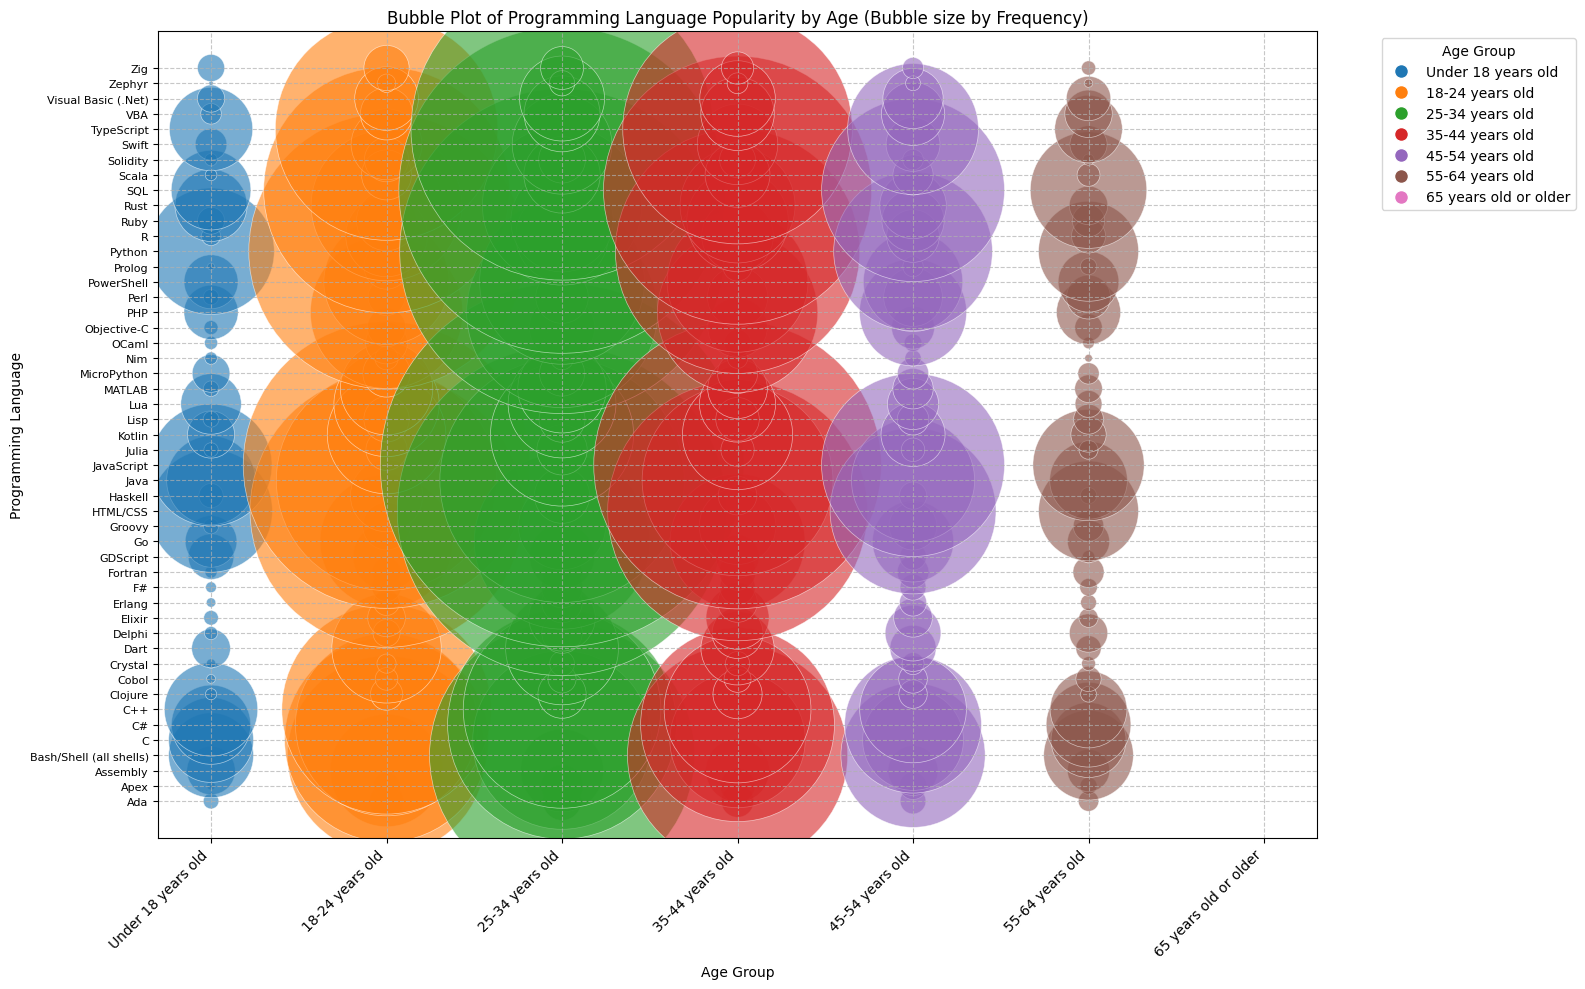

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Drop rows where 'Age' or 'LanguageHaveWorkedWith' is NaN
df_plot3 = df.dropna(subset=['Age', 'LanguageHaveWorkedWith']).copy()

# Define a consistent order for 'Age'
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years old or older'
]
df_plot3['Age'] = pd.Categorical(df_plot3['Age'], categories=age_order, ordered=True)

# Split the 'LanguageHaveWorkedWith' column into individual languages
df_plot3['LanguageHaveWorkedWith'] = df_plot3['LanguageHaveWorkedWith'].str.split(';')

# Explode the DataFrame to have one row per language for each respondent
df_plot3_exploded = df_plot3.explode('LanguageHaveWorkedWith')

# Aggregate data: count the frequency of each language within each age group
df_agg3 = df_plot3_exploded.groupby(['Age', 'LanguageHaveWorkedWith']).agg(
    language_count=('ResponseId', 'count')
).reset_index()

# Filter out languages with very low counts if desired for clarity (optional)
# For example, only include languages with count > 50
# df_agg3 = df_agg3[df_agg3['language_count'] > 50]

# Scale the language count for bubble size
# Adjust multiplier as needed for visual clarity. Max size should be reasonable.
size_multiplier = 5 # Adjust based on max count values
df_agg3['bubble_size'] = df_agg3['language_count'] * size_multiplier

# Create the bubble plot
plt.figure(figsize=(16, 10))

# Map Age categories to a color map
age_colors_cmap = plt.colormaps.get_cmap('tab10')
age_color_map = {age_group: age_colors_cmap(i) for i, age_group in enumerate(age_order)}

# Convert 'Age' to string before mapping to color for robustness
df_agg3['Age_Color'] = df_agg3['Age'].astype(str).map(age_color_map)

scatter = plt.scatter(
    x=df_agg3['Age'],
    y=df_agg3['LanguageHaveWorkedWith'],
    s=df_agg3['bubble_size'],  # Size determined by language count
    alpha=0.6,
    c=df_agg3['Age_Color'],    # Color by Age Group
    edgecolors='w',
    linewidth=0.5
)

# Create custom legend for age groups
handles = [plt.Line2D([0], [0], marker='o', color='w', label=age_group,
                      markerfacecolor=age_color_map[age_group], markersize=10) for age_group in age_order]
plt.legend(handles=handles, title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Age Group')
plt.ylabel('Programming Language')
plt.title('Bubble Plot of Programming Language Popularity by Age (Bubble size by Frequency)')

# Rotate x-axis labels if they are too long
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=8) # Adjust font size for y-axis if many languages

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Preferred Databases vs. Job Satisfaction

- Explore the relationship between preferred databases (`DatabaseWantToWorkWith`) and job satisfaction.

- Use bubble size to indicate the number of respondents for each database.


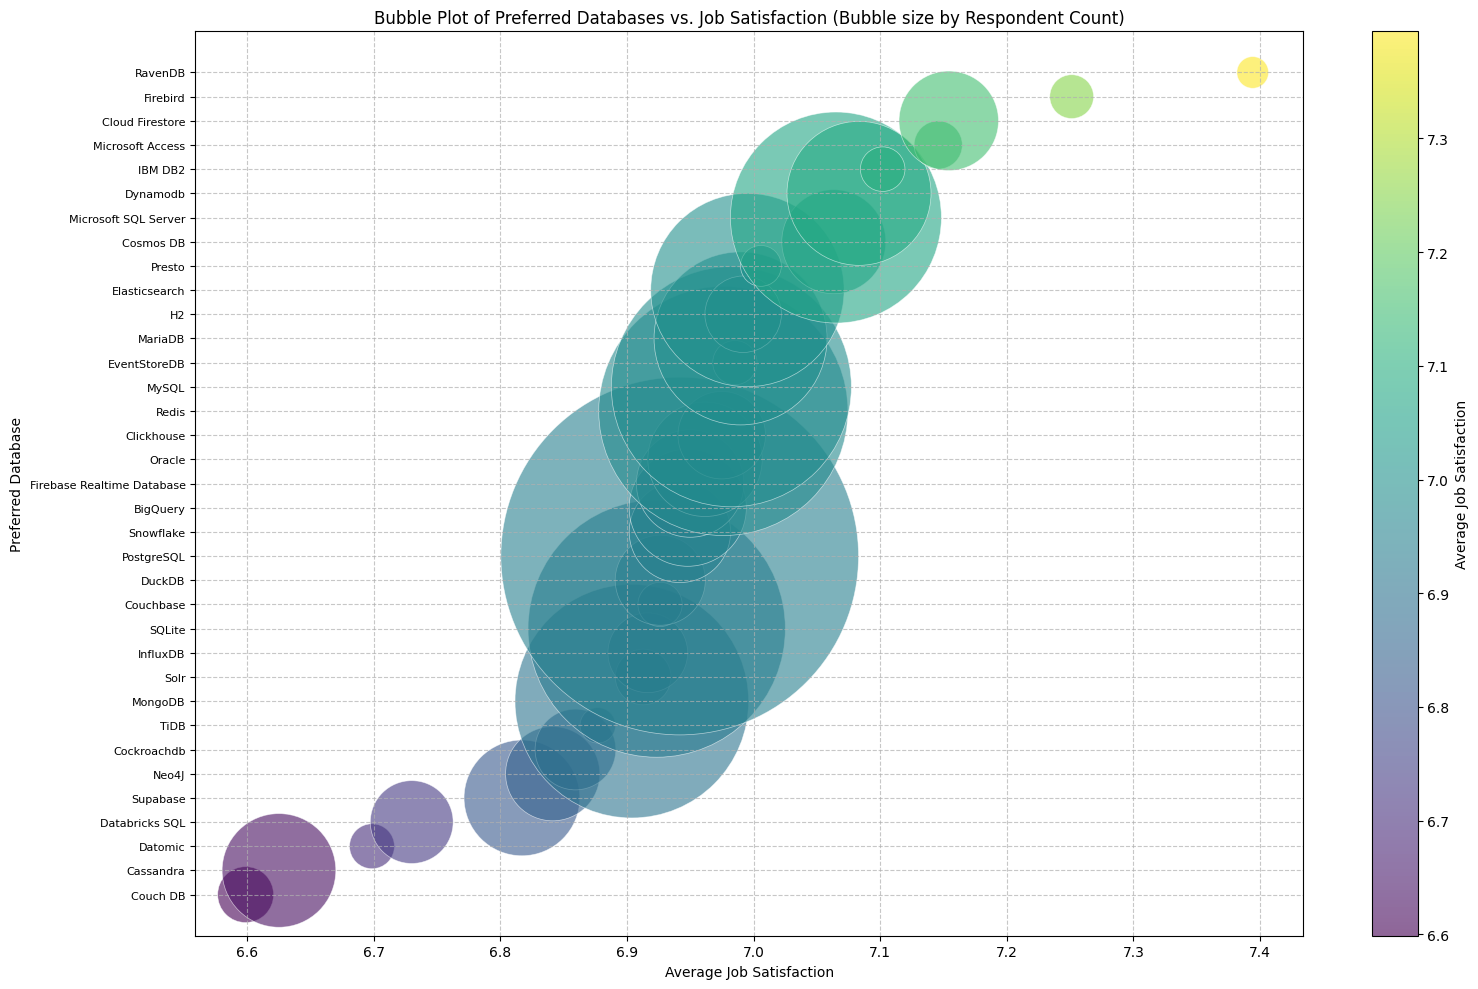

In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Drop rows where 'DatabaseWantToWorkWith' or 'JobSat' is NaN
df_plot4 = df.dropna(subset=['DatabaseWantToWorkWith', 'JobSat']).copy()

# Split the 'DatabaseWantToWorkWith' column into individual databases
df_plot4['DatabaseWantToWorkWith'] = df_plot4['DatabaseWantToWorkWith'].str.split(';')

# Explode the DataFrame to have one row per database for each respondent
df_plot4_exploded = df_plot4.explode('DatabaseWantToWorkWith')

# Convert JobSat to numeric. Ensure it's a number for averaging.
df_plot4_exploded['JobSat'] = pd.to_numeric(df_plot4_exploded['JobSat'], errors='coerce')

# Drop any rows where JobSat became NaN after conversion
df_plot4_exploded.dropna(subset=['JobSat'], inplace=True)

# Aggregate data: calculate mean JobSat and count of respondents for each database
df_agg4 = df_plot4_exploded.groupby('DatabaseWantToWorkWith').agg(
    mean_job_sat=('JobSat', 'mean'),
    count_respondents=('ResponseId', 'count')
).reset_index()

# Scale the count of respondents for bubble size
size_multiplier = 5 # Adjust as needed for visual clarity
df_agg4['bubble_size'] = df_agg4['count_respondents'] * size_multiplier

# Sort by mean_job_sat to get a color gradient or just plot as is
df_agg4 = df_agg4.sort_values(by='mean_job_sat', ascending=True)

# Create the bubble plot
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    x=df_agg4['mean_job_sat'],         # X-axis: Average Job Satisfaction
    y=df_agg4['DatabaseWantToWorkWith'], # Y-axis: Preferred Database
    s=df_agg4['bubble_size'],           # Size determined by count of respondents
    alpha=0.6,
    c=df_agg4['mean_job_sat'],          # Color determined by mean JobSat
    cmap='viridis',                     # Color map
    edgecolors='w',
    linewidth=0.5
)

# Add a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Average Job Satisfaction')

plt.xlabel('Average Job Satisfaction')
plt.ylabel('Preferred Database')
plt.title('Bubble Plot of Preferred Databases vs. Job Satisfaction (Bubble size by Respondent Count)')

# Rotate y-axis labels if they are too long and adjust font size
plt.yticks(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 3: Comparing Data Using Bubble Plots


#### 1. Bubble Plot for Compensation Across Developer Roles

- Visualize compensation (`ConvertedCompYearly`) across different developer roles (`DevType`).

- Use bubble size to represent job satisfaction.


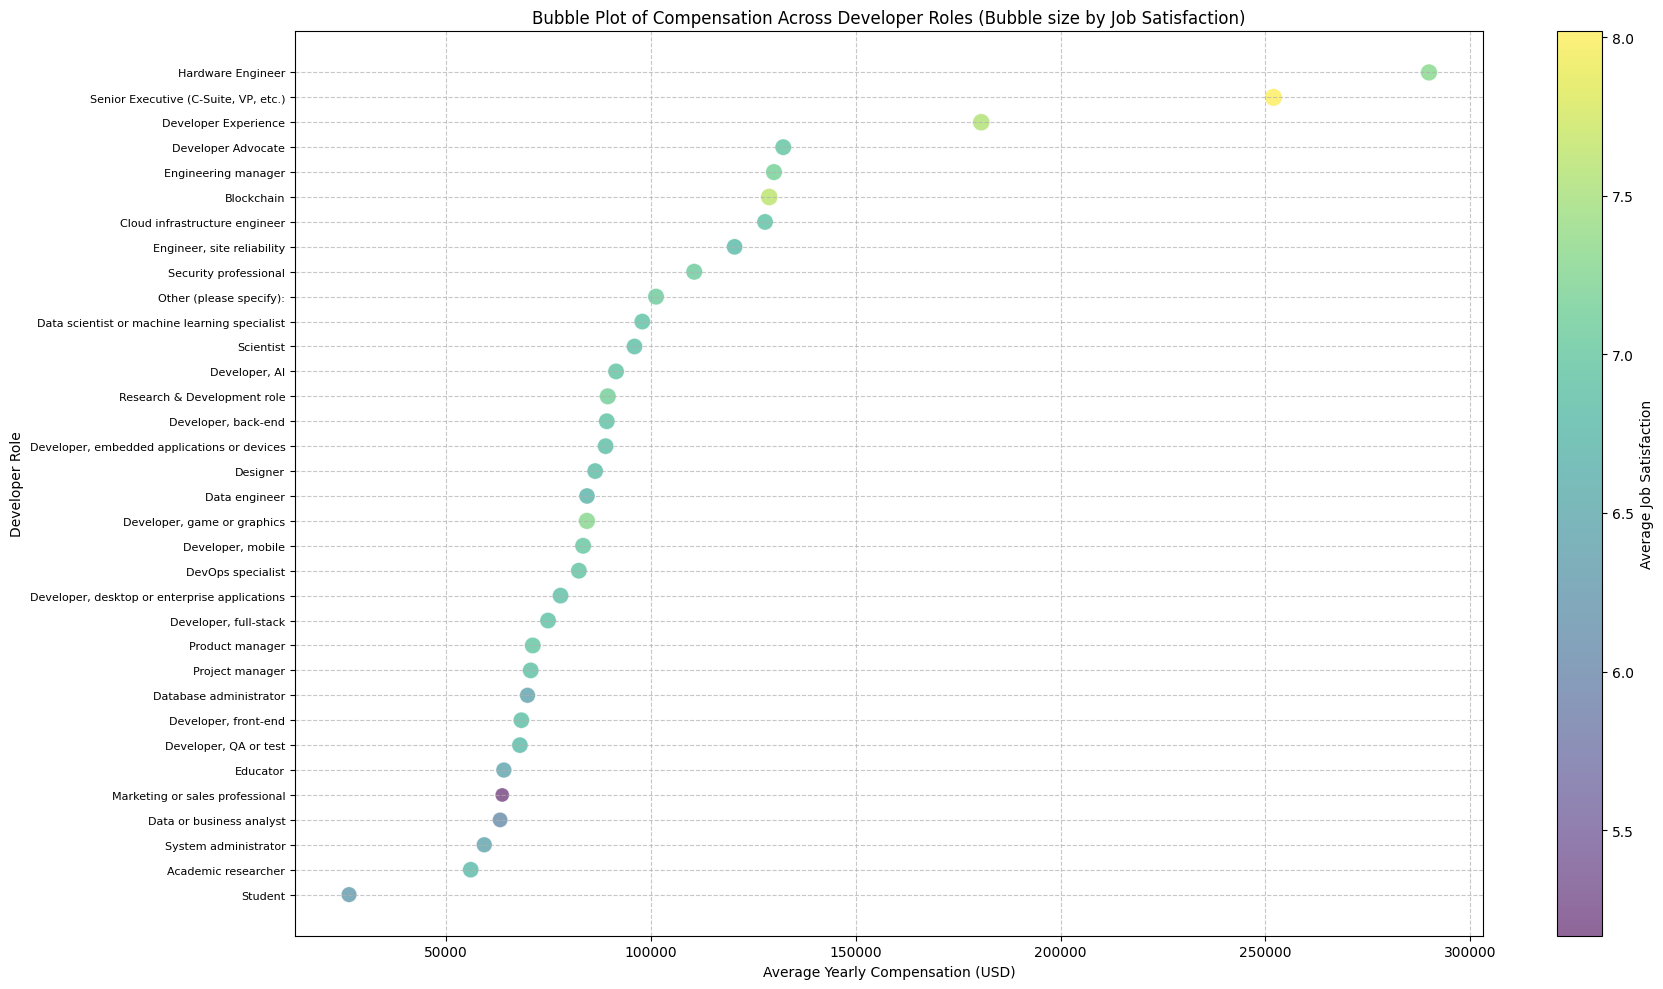

In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Drop rows where 'DevType', 'ConvertedCompYearly', or 'JobSat' is NaN
df_plot5 = df.dropna(subset=['DevType', 'ConvertedCompYearly', 'JobSat']).copy()

# Split the 'DevType' column into individual developer roles
df_plot5['DevType'] = df_plot5['DevType'].str.split(';')

# Explode the DataFrame to have one row per developer role for each respondent
df_plot5_exploded = df_plot5.explode('DevType')

# Convert 'ConvertedCompYearly' and 'JobSat' to numeric, coercing errors
df_plot5_exploded['ConvertedCompYearly'] = pd.to_numeric(df_plot5_exploded['ConvertedCompYearly'], errors='coerce')
df_plot5_exploded['JobSat'] = pd.to_numeric(df_plot5_exploded['JobSat'], errors='coerce')

# Drop rows where conversion resulted in NaN for these columns
df_plot5_exploded.dropna(subset=['ConvertedCompYearly', 'JobSat'], inplace=True)

# Aggregate data: calculate mean compensation and mean job satisfaction for each developer role
df_agg5 = df_plot5_exploded.groupby('DevType').agg(
    mean_compensation=('ConvertedCompYearly', 'mean'),
    mean_job_sat=('JobSat', 'mean'),
    count_respondents=('ResponseId', 'count')
).reset_index()

# Scale mean_job_sat for bubble size
# Adjust multiplier as needed for visual clarity. Max size should be reasonable.
size_multiplier = 20 # Example multiplier, adjust based on your JobSat range and desired bubble size
df_agg5['bubble_size'] = df_agg5['mean_job_sat'] * size_multiplier

# Sort by mean_compensation for better visualization if desired
df_agg5 = df_agg5.sort_values(by='mean_compensation', ascending=True)

# Create the bubble plot
plt.figure(figsize=(18, 10))

scatter = plt.scatter(
    x=df_agg5['mean_compensation'],   # X-axis: Mean Compensation
    y=df_agg5['DevType'],             # Y-axis: Developer Role
    s=df_agg5['bubble_size'],         # Size determined by scaled mean JobSat
    alpha=0.6,
    c=df_agg5['mean_job_sat'],        # Color determined by mean JobSat
    cmap='viridis',                   # Color map
    edgecolors='w',
    linewidth=0.5
)

# Add a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Average Job Satisfaction')

plt.xlabel('Average Yearly Compensation (USD)')
plt.ylabel('Developer Role')
plt.title('Bubble Plot of Compensation Across Developer Roles (Bubble size by Job Satisfaction)')

# Rotate y-axis labels if they are too long and adjust font size
plt.yticks(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Collaboration Tools by Age

- Visualize the relationship between the collaboration tools used (`NEWCollabToolsHaveWorkedWith`) and age groups.

- Use bubble size to represent the frequency of tool usage.


/tmp/ipykernel_152/2891704408.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_agg6 = df_plot6_exploded.groupby(['Age', 'NEWCollabToolsHaveWorkedWith']).agg(


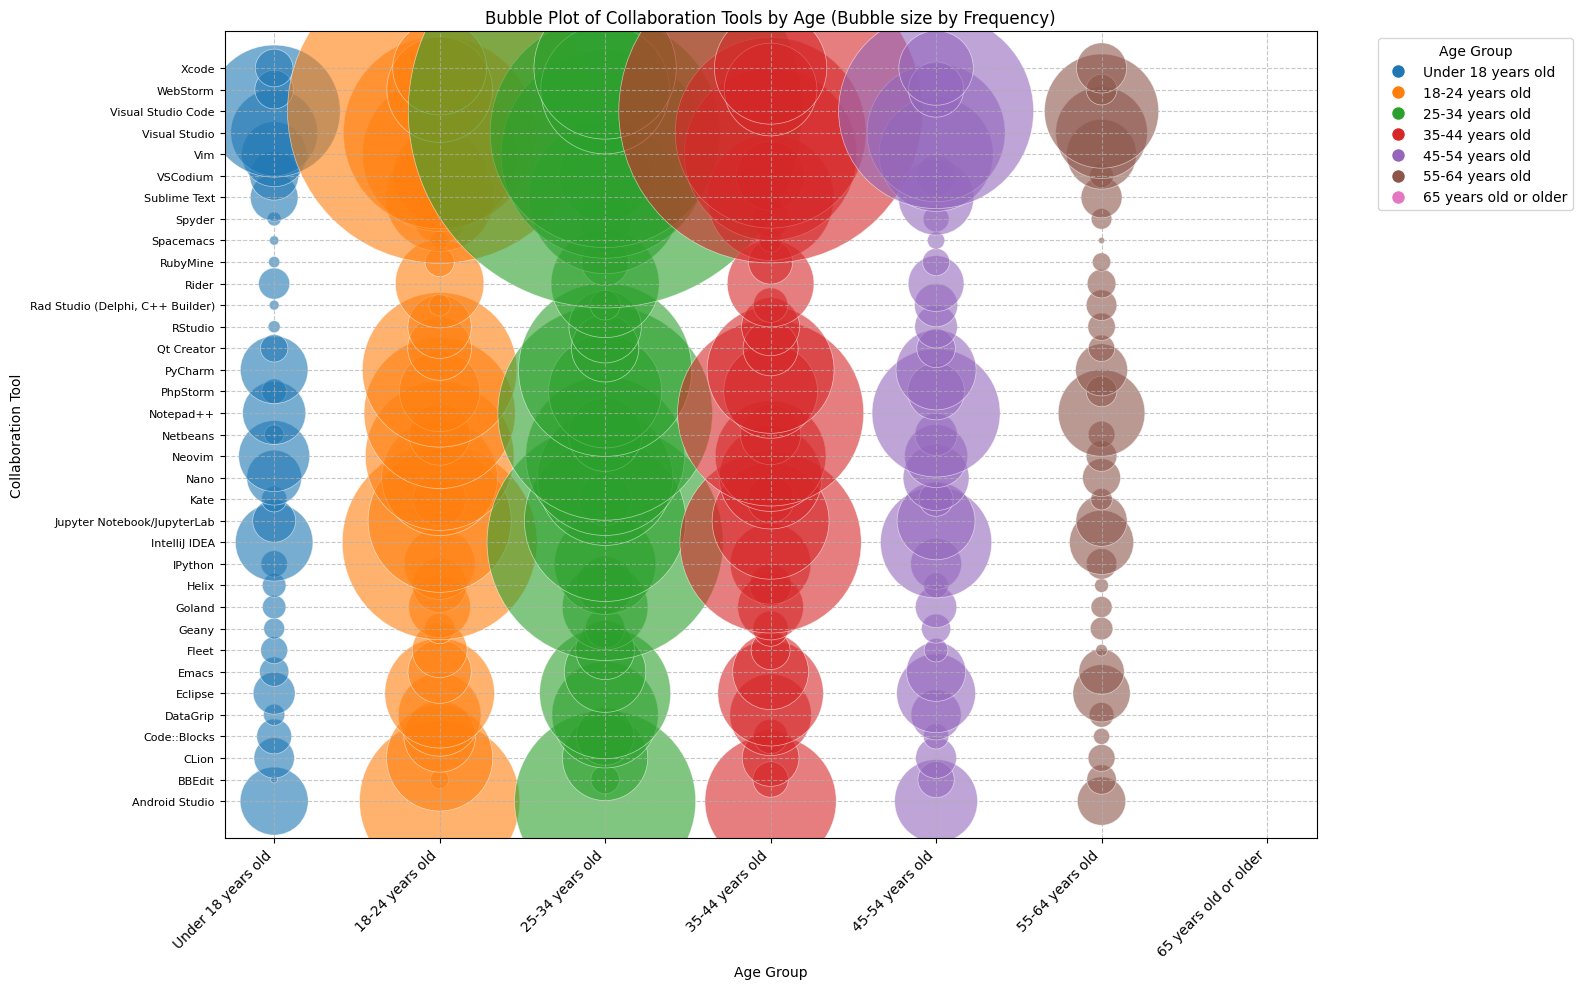

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Drop rows where 'Age' or 'NEWCollabToolsHaveWorkedWith' is NaN
df_plot6 = df.dropna(subset=['Age', 'NEWCollabToolsHaveWorkedWith']).copy()

# Define a consistent order for 'Age'
age_order = [
    'Under 18 years old',
    '18-24 years old',
    '25-34 years old',
    '35-44 years old',
    '45-54 years old',
    '55-64 years old',
    '65 years old or older'
]
df_plot6['Age'] = pd.Categorical(df_plot6['Age'], categories=age_order, ordered=True)

# Split the 'NEWCollabToolsHaveWorkedWith' column into individual tools
df_plot6['NEWCollabToolsHaveWorkedWith'] = df_plot6['NEWCollabToolsHaveWorkedWith'].str.split(';')

# Explode the DataFrame to have one row per tool for each respondent
df_plot6_exploded = df_plot6.explode('NEWCollabToolsHaveWorkedWith')

# Aggregate data: count the frequency of each tool within each age group
df_agg6 = df_plot6_exploded.groupby(['Age', 'NEWCollabToolsHaveWorkedWith']).agg(
    tool_count=('ResponseId', 'count')
).reset_index()

# Filter out tools with very low counts if desired for clarity (optional)
# df_agg6 = df_agg6[df_agg6['tool_count'] > 10]

# Scale the tool count for bubble size
size_multiplier = 5 # Adjust based on max count values
df_agg6['bubble_size'] = df_agg6['tool_count'] * size_multiplier

# Create the bubble plot
plt.figure(figsize=(16, 10))

# Map Age categories to a color map
age_colors_cmap = plt.colormaps.get_cmap('tab10')
age_color_map = {age_group: age_colors_cmap(i) for i, age_group in enumerate(age_order)}

# Convert 'Age' to string before mapping to color for robustness
df_agg6['Age_Color'] = df_agg6['Age'].astype(str).map(age_color_map)

scatter = plt.scatter(
    x=df_agg6['Age'],
    y=df_agg6['NEWCollabToolsHaveWorkedWith'],
    s=df_agg6['bubble_size'],  # Size determined by tool count
    alpha=0.6,
    c=df_agg6['Age_Color'],    # Color by Age Group
    edgecolors='w',
    linewidth=0.5
)

# Create custom legend for age groups
handles = [plt.Line2D([0], [0], marker='o', color='w', label=age_group,
                      markerfacecolor=age_color_map[age_group], markersize=10) for age_group in age_order]
plt.legend(handles=handles, title='Age Group', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Age Group')
plt.ylabel('Collaboration Tool')
plt.title('Bubble Plot of Collaboration Tools by Age (Bubble size by Frequency)')

# Rotate x-axis labels if they are too long
plt.xticks(rotation=45, ha='right')
plt.yticks(fontsize=8) # Adjust font size for y-axis if many tools

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Task 4: Visualizing Technology Trends Using Bubble Plots


#### 1. Bubble Plot for Preferred Web Frameworks vs. Job Satisfaction

- Explore the relationship between preferred web frameworks (`WebframeWantToWorkWith`) and job satisfaction.

- Use bubble size to represent the number of respondents.



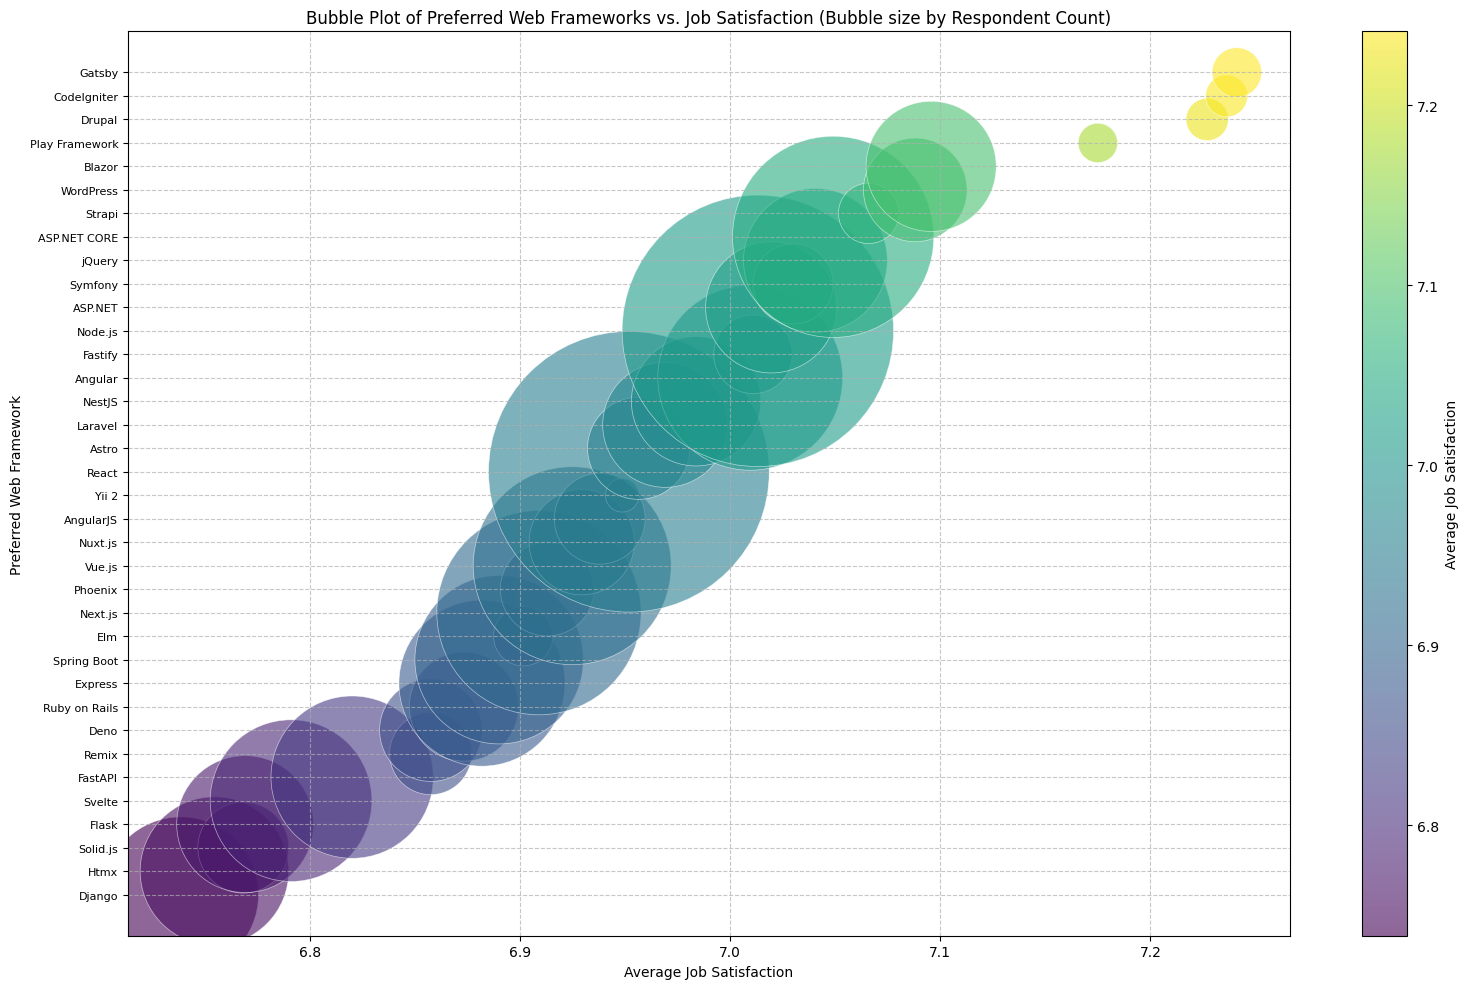

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Drop rows where 'WebframeWantToWorkWith' or 'JobSat' is NaN
df_plot7 = df.dropna(subset=['WebframeWantToWorkWith', 'JobSat']).copy()

# Split the 'WebframeWantToWorkWith' column into individual frameworks
df_plot7['WebframeWantToWorkWith'] = df_plot7['WebframeWantToWorkWith'].str.split(';')

# Explode the DataFrame to have one row per framework for each respondent
df_plot7_exploded = df_plot7.explode('WebframeWantToWorkWith')

# Convert JobSat to numeric. Ensure it's a number for averaging.
df_plot7_exploded['JobSat'] = pd.to_numeric(df_plot7_exploded['JobSat'], errors='coerce')

# Drop any rows where JobSat became NaN after conversion
df_plot7_exploded.dropna(subset=['JobSat'], inplace=True)

# Aggregate data: calculate mean JobSat and count of respondents for each web framework
df_agg7 = df_plot7_exploded.groupby('WebframeWantToWorkWith').agg(
    mean_job_sat=('JobSat', 'mean'),
    count_respondents=('ResponseId', 'count')
).reset_index()

# Scale the count of respondents for bubble size
size_multiplier = 5 # Adjust as needed for visual clarity
df_agg7['bubble_size'] = df_agg7['count_respondents'] * size_multiplier

# Sort by mean_job_sat to get a color gradient or just plot as is
df_agg7 = df_agg7.sort_values(by='mean_job_sat', ascending=True)

# Create the bubble plot
plt.figure(figsize=(16, 10))

scatter = plt.scatter(
    x=df_agg7['mean_job_sat'],         # X-axis: Average Job Satisfaction
    y=df_agg7['WebframeWantToWorkWith'], # Y-axis: Preferred Web Framework
    s=df_agg7['bubble_size'],           # Size determined by count of respondents
    alpha=0.6,
    c=df_agg7['mean_job_sat'],          # Color determined by mean JobSat
    cmap='viridis',                     # Color map
    edgecolors='w',
    linewidth=0.5
)

# Add a color bar
cbar = plt.colorbar(scatter)
cbar.set_label('Average Job Satisfaction')

plt.xlabel('Average Job Satisfaction')
plt.ylabel('Preferred Web Framework')
plt.title('Bubble Plot of Preferred Web Frameworks vs. Job Satisfaction (Bubble size by Respondent Count)')

# Rotate y-axis labels if they are too long and adjust font size
plt.yticks(fontsize=8)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### 2. Bubble Plot for Admired Technologies Across Countries

- Visualize the distribution of admired technologies (`LanguageAdmired`) across different countries (`Country`).

- Use bubble size to represent the frequency of admiration.



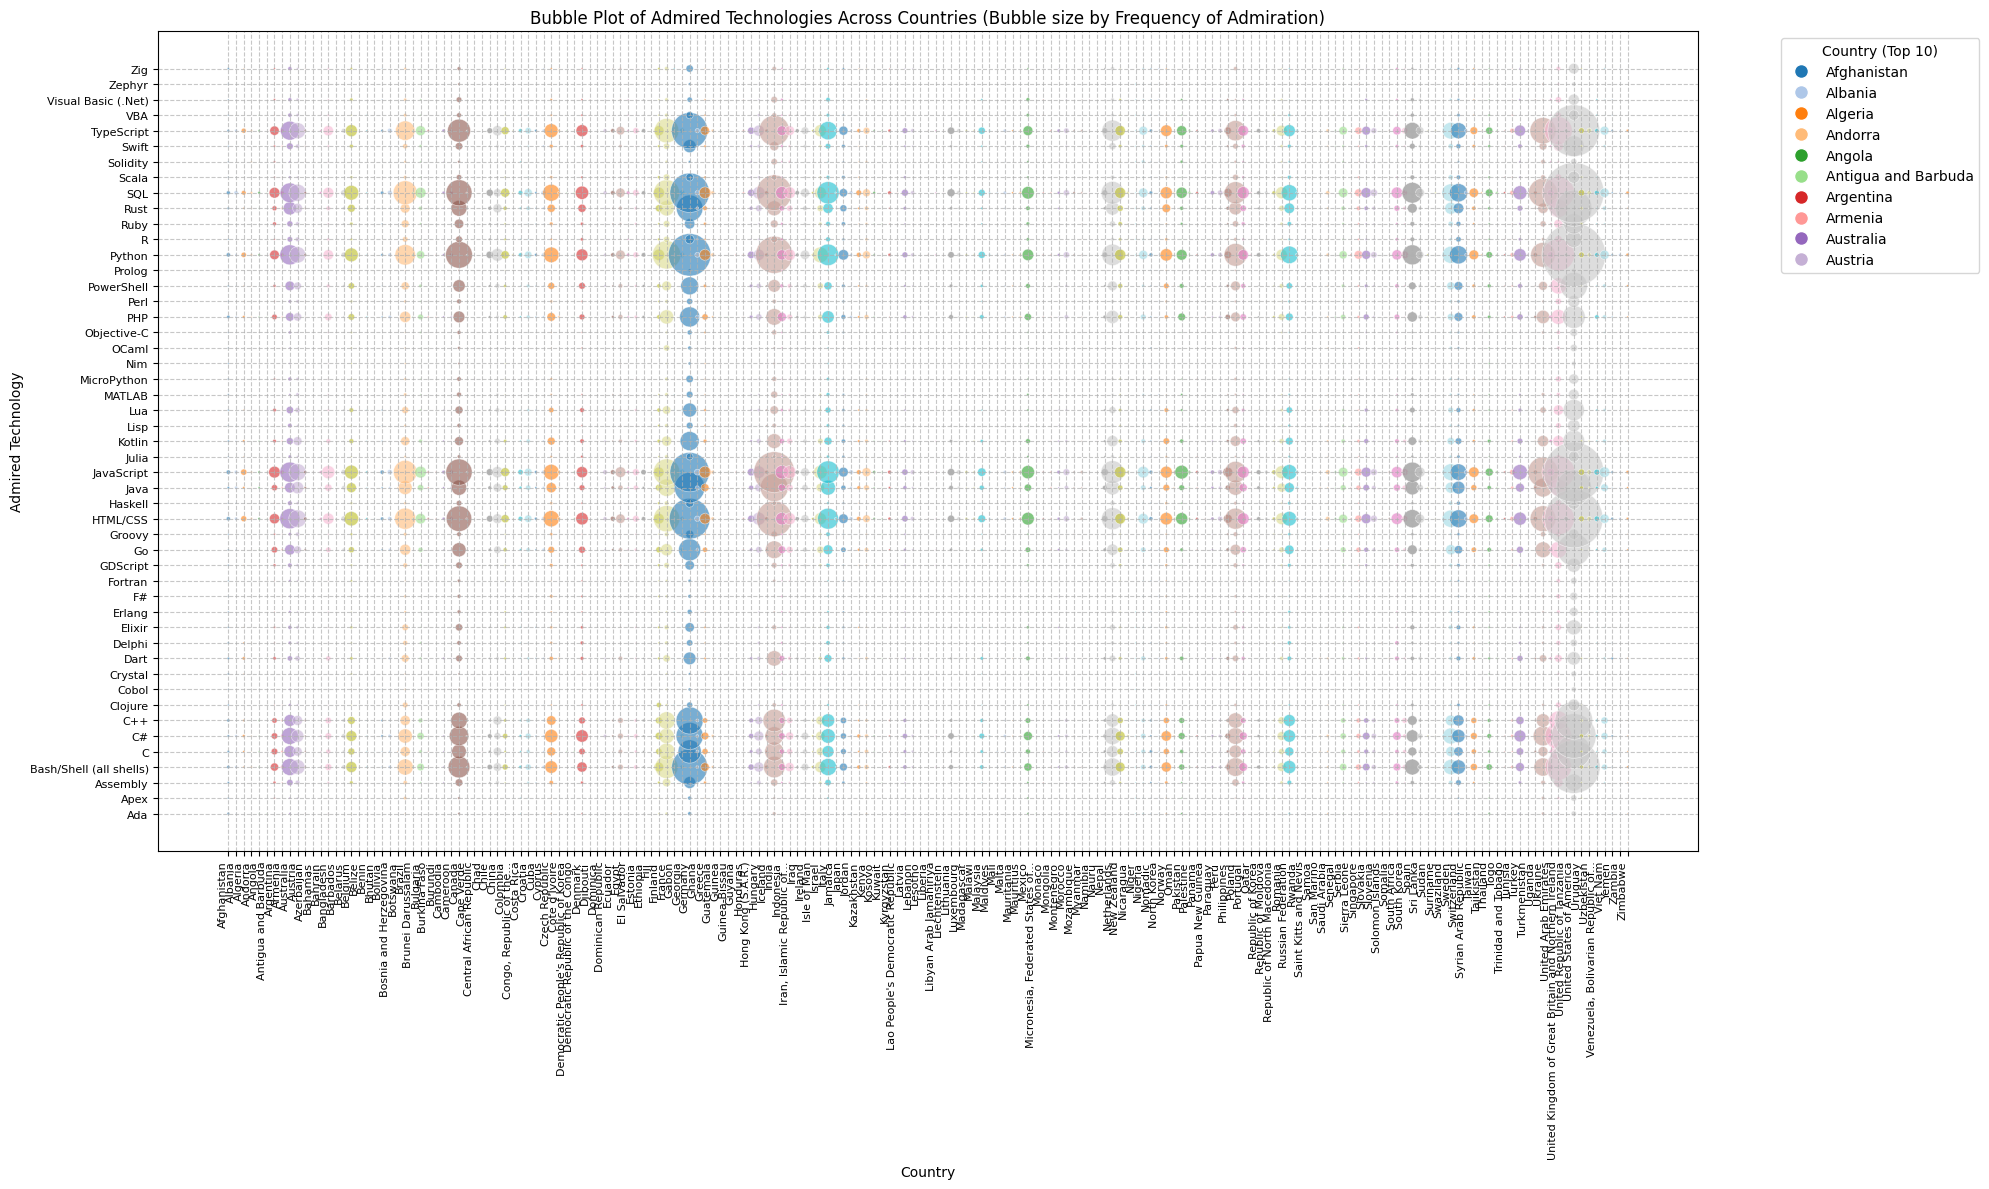

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Drop rows where 'Country' or 'LanguageAdmired' is NaN
df_plot8 = df.dropna(subset=['Country', 'LanguageAdmired']).copy()

# Split the 'LanguageAdmired' column into individual technologies
df_plot8['LanguageAdmired'] = df_plot8['LanguageAdmired'].str.split(';')

# Explode the DataFrame to have one row per admired technology for each respondent
df_plot8_exploded = df_plot8.explode('LanguageAdmired')

# Aggregate data: count the frequency of each admired technology within each country
df_agg8 = df_plot8_exploded.groupby(['Country', 'LanguageAdmired']).agg(
    admiration_count=('ResponseId', 'count')
).reset_index()

# Filter out technologies/countries with very low counts if desired for clarity (optional)
# df_agg8 = df_agg8[df_agg8['admiration_count'] > 10]

# Scale the admiration count for bubble size
size_multiplier = 0.5 # Adjust as needed for visual clarity
df_agg8['bubble_size'] = df_agg8['admiration_count'] * size_multiplier

# Get a list of unique countries for coloring
countries = df_agg8['Country'].unique()

# Create the bubble plot
plt.figure(figsize=(20, 12))

# Use a colormap for countries for better differentiation
country_colors_cmap = plt.colormaps.get_cmap('tab20') # 'tab20' is good for up to 20 distinct colors

# Create a mapping from country name to color
country_color_map = {country: country_colors_cmap(i % 20) for i, country in enumerate(countries)}

# Assign colors to the DataFrame based on country
df_agg8['Country_Color'] = df_agg8['Country'].map(country_color_map)

scatter = plt.scatter(
    x=df_agg8['Country'],
    y=df_agg8['LanguageAdmired'],
    s=df_agg8['bubble_size'],  # Size determined by admiration count
    alpha=0.6,
    c=df_agg8['Country_Color'], # Color by Country
    edgecolors='w',
    linewidth=0.5
)

# Create custom legend for countries
handles = [plt.Line2D([0], [0], marker='o', color='w', label=country,
                      markerfacecolor=country_color_map[country], markersize=10) for country in countries[:10]] # Show first 10 countries in legend for brevity
plt.legend(handles=handles, title='Country (Top 10)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xlabel('Country')
plt.ylabel('Admired Technology')
plt.title('Bubble Plot of Admired Technologies Across Countries (Bubble size by Frequency of Admiration)')

# Rotate x-axis labels for readability
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(fontsize=8) # Adjust font size for y-axis if many technologies

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Final Step: Review


After completing the lab, you will have extensively used bubble plots to gain insights into developer community preferences, demographics, compensation trends, and job satisfaction.


## Summary


After completing this lab, you will be able to:

- Create and interpret bubble plots to analyze relationships and compositions within datasets.

- Use bubble plots to explore developer preferences, compensation trends, and satisfaction levels.

- Apply bubble plots to visualize complex relationships involving multiple dimensions effectively.


## Authors:
Sumant.chakravarty@gmail.com
